# 5 注意力机制介绍

## 学习目标
- 了解什么是注意力计算规则以及常见的计算规则。
- 了解什么是注意力机制及其作用。
- 掌握注意力机制的实现步骤。

---

# 1 注意力机制介绍

## 1.1 注意力概念
- 我们观察事物时，之所以能够快速判断一种事物(当然允许判断是错误的)，是因为我们大脑能够很快把注意力放在事物最具有辨识度的部分从而作出判断，而并非是从头到尾的观察一遍事物后，才能有判断结果。正是基于这样的理论，就产生了注意力机制。

## 1.2 注意力计算规则
- 它需要三个指定的输入 \( Q(query), K(key), V(value) \)，然后通过计算公式得到注意力的结果，这个结果代表 \( query \) 在 \( key \) 和 \( value \) 作用下的注意力表示。当输入的 \( Q=K=V \) 时，称作自注意力计算规则。
- \( Q, K, V \) 的比喻解释：

## 💡 第一性原理：为什么Q、K、V恰好是三个？

> **回到最根本的问题**：给出一段文本，如何让计算机用关键词来描述它？

人类做这件事只需要两步：**1）扫描**——哪些词最关键？**2）聚焦**——把注意力集中在这些词上。

让计算机模拟这个过程，我们需要三个独立的功能：

| 功能 | 对应角色 | 要回答的问题 |
|------|----------|-------------|
| 知道你要**找什么** | **Q（Query）** | "我需要什么信息？" |
| 知道哪些信息**值得关注** | **K（Key）** | "我是什么，来匹配我" |
| 提取**有价值的内容** | **V（Value）** | "匹配到我后，我把实际内容给你" |

**为什么不是两个？** 如果只有 Query 和 Content，那么"匹配索引"和"实际内容"用同一套表示——词在"被找到"和"被读取"时被迫使用相同的特征，两者互相妥协。Q、K、V三者分离让"找谁"和"取什么"可以独立优化。

**为什么不是四个？** 三个已经是"选择性信息提取"问题的最小完备解，第四个只会增加冗余。

假如我们有一个问题：给出一段文本，使用一些关键词对它进行描述！

为了方便统一正确答案，这道题可能预先已经给大家写出了一些关键词作为提示，其中这些给出的提示就可以看作是 key，而整个的文本信息就相当于是 query，value 的含义则更抽象，可以比作是你看到这段文本信息后，脑子里浮现的答案信息。

这里我们假设大家最开始都不是很聪明，第一次看到这段文本后脑子里基本上浮现的信息就只有提示这些信息，因此 key 与 value 基本是相同的，但是随着我们对这个问题的深入理解，通过我们的思考脑子里想起来的答案越来越多，并且能够开始对我们 query 也就是这段文本，提取关键词信息进行表示。这就是注意力作用的过程，通过这个过程，我们最终脑子里的 value 发生了变化，根据提示 key 生成了 query 的关键词表示方法，也就是另外一种特征表示方法。

刚刚我们说到 key 和 value 一般情况下默认是相同，与 query 是不同的，这种是我们一般的注意力输入形式，但有一种特殊情况，就是我们 query 与 key 和 value 相同，这种情况下我们称为自注意力机制，就如同我们刚刚的例子，使用一般注意力机制，是使用不同于给定文本的关键词表示它。而自注意力机制，需要用到给定文本自身来表达自己，也就是说你需要从给定文本中抽取关键词来表达它，相当于对文本自身的一次特征提取。

## 🎓 费曼学习法：三个生活类比理解Q、K、V

### 类比一：图书馆找书（最接近本质）

```
你走进图书馆，想找关于"鲁迅文学"的书。
```

| 角色 | 对应 | 场景中的含义 |
|------|------|-------------|
| **Q（查询）** | 你的需求 | "我想找关于鲁迅文学的书" |
| **K（键/索引）** | 书的标签 | 每本书的书名、分类标签 |
| **V（值/内容）** | 书的实际内容 | 书里写了什么 |

**三步过程**：

```
第1步 — 匹配（Q × K）：你用需求去匹配每本书的标签
    "鲁迅文学" vs "鲁迅全集"       → 匹配度 0.80
    "鲁迅文学" vs "Python机器学习"  → 匹配度 0.01
    "鲁迅文学" vs "鲁迅与近代文学"  → 匹配度 0.90

第2步 — 归一化（Softmax）：匹配度变成时间分配比例
    书A: 35%  书B: 2%  书C: 63%    ← 花63%时间读最相关的

第3步 — 读取（× V）：按比例读取每本书的实际内容
    你的知识 = 0.35×V_A + 0.02×V_B + 0.63×V_C
```

> **关键洞察**：K 决定你**选**哪本书，V 才是你**读**的内容。同一本书，K 和 V 指向同一个东西但扮演不同角色——就像书名和正文的关系。

### 类比二：Google 搜索

| 角色 | 对应 |
|------|------|
| **Q** | 你在搜索框输入的关键词 |
| **K** | 每个网页的标题、摘要、关键词 |
| **V** | 每个网页的完整内容 |

搜索引擎做的事和注意力机制一模一样：用 Q 匹配 K → 排序 → 按相关性展示 V 的内容。

### 类比三：考试答题（笔记原文的翻译）

| 角色 | 对应 |
|------|------|
| **Q** | 试卷上的原文："请描述这段话" |
| **K** | 题目给的提示关键词 |
| **V** | 你脑子里根据提示浮现的答案 |

一般注意力：Q ≠ K = V（用外部提示来描述文本）
自注意力：Q = K = V（用文本自身来描述自己，即从给定文本中抽取关键词来表达它）

## 1.3 常见的注意力计算规则

* 将 Q, K 进行纵轴拼接，做一次线性变化，再使用 softmax 处理获得结果最后与 V 做张量乘法.
  $$\text{Attention}(Q, K, V) = \text{Softmax}(\text{Linear}([Q, K])) \cdot V$$

* 将 Q, K 进行纵轴拼接，做一次线性变化后再使用 tanh 函数激活，然后再进行内部求和，最后使用 softmax 处理获得结果再与 V 做张量乘法.
  $$\text{Attention}(Q, K, V) = \text{Softmax}(\sum(\tanh(\text{Linear}([Q, K])))) \cdot V$$

* 将 Q 与 K 的转置做点积运算，然后除以一个缩放系数，再使用 softmax 处理获得结果最后与 V 做张量乘法.
  $$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{Q \cdot K^T}{\sqrt{d_k}}\right) \cdot V$$

* 说明：当注意力权重矩阵和 V 都是三维张量且第一维代表为 batch 条数时，则做 bmm 运算.bmm 是一种特殊的张量乘法运算.

* bmm运算演示：

In [ ]:
# 如果参数1形状是(b x n x m)，参数2形状是(b x m x p)，则输出为(b x n x p)
input = torch.randn(10, 3, 4)
mat2 = torch.randn(10, 4, 5)
res = torch.bmm(input, mat2)
res.size()
torch.Size([10, 3, 5])

## 🔢 手算演示：自注意力的完整计算过程

以句子 **"我 爱 你"** 为例，词向量维度 d=4，展示 Q、K、V 的每一步计算。

### Step 1：词向量（Embedding）

```
"我": [1.0, 0.0, 1.0, 0.0]    ← 主语/名词特征
"爱": [0.0, 1.0, 0.0, 1.0]    ← 动词/情感特征
"你": [1.0, 1.0, 0.0, 0.0]    ← 宾语/人称特征
```

### Step 2：通过权重矩阵生成 Q、K、V

> 原始向量分别乘以三个**不同的**权重矩阵（这是可学习的参数！），产生分工明确的 Q、K、V。

```python
W_Q = [[0.8, 0.2],    # 偏向第1维 → Q 关注"谁在句子里"
       [0.2, 0.1]]

W_K = [[0.8, 0.2],    # 偏向第1维 → K 标注"我是名词/主语"
       [0.2, 0.1]]

W_V = [[0.1, 0.1],    # 偏向第2维 → V 携带"怎么样"的信息
       [1.0, 0.8]]
```

计算后每个词的 Q、K、V（简化为2维以便手算）：

| 词 | Q（问什么） | K（能匹配什么） | V（有什么内容） |
|---|-----------|---------------|---------------|
| "苹果" | [0.8, 0.2] | [0.8, 0.2] | [0.1, 0.1] ← 内容量少 |
| "好吃" | [0.2, 0.1] | [0.2, 0.1] | [1.0, 0.8] ← 内容量多！ |

> **关键发现**：同一个词，"匹配能力"和"信息含量"可以完全不同！
> "好吃"的 K 值低（不容易被匹配到），但 V 值高（一旦被匹配，贡献大量信息）
> 这就是 Q、K、V 必须分离的第一性原因。

### Step 3：计算注意力分数 — Q × K^T

```
"苹果"问所有词：
  问"苹果": Q₁·K₁ = 0.8×0.8 + 0.2×0.2 = 0.64 + 0.04 = 0.68  ← 和自己最相关
  问"好吃": Q₁·K₂ = 0.8×0.2 + 0.2×0.1 = 0.16 + 0.02 = 0.18

分数矩阵：
         "苹果"  "好吃"
"苹果" [ 0.68,   0.18 ]
"好吃" [ 0.18,   0.68 ]
```

### Step 4：缩放 + Softmax = 注意力权重

```
"苹果"行: [0.68, 0.18] ÷ √2 = [0.48, 0.13]
         → Softmax → [0.62, 0.38]
         → "苹果" 62% 注意自己，38% 注意"好吃"
```

### Step 5：加权求和 — 权重 × V

```
"苹果"的新表示 = 0.62 × V₁ + 0.38 × V₂
              = 0.62 × [0.1, 0.1] + 0.38 × [1.0, 0.8]
              = [0.062, 0.062] + [0.38, 0.304]
              = [0.442, 0.366]

对比:
  输入 "苹果":  [1.00,  0.00]   ← 只知道自己是名词
  输出 "苹果":  [0.442, 0.366]  ← 带上了"好吃"的语义，知道自己是"好吃的苹果"！
```

> **注意力机制的本质**：每个词不再是孤立的符号，而是整句话中所有词的**加权融合**。权重由 Q-K 匹配决定，内容由 V 提供——三者各司其职，缺一不可。

## 2 什么是注意力机制

- 注意力机制是注意力计算规则能够应用的深度学习网络的载体，同时包括一些必要的全连接层以及相关张量处理，使其与应用网络融为一体。使用自注意力计算规则的注意力机制称为自注意力机制。

- 说明：NLP领域中，当前的注意力机制大多数应用于seq2seq架构，即编码器和解码器模型。

## 3 注意力机制的作用

- 在解码器端的注意力机制：能够根据模型目标有效的聚焦编码器的输出结果，当其作为解码器的输入时提升效果。改善以往编码器输出是单一长张量，无法存储过多信息的情况。

- 在编码器端的注意力机制：主要解决表征问题，相当于特征提取过程，得到输入的注意力表示。一般使用自注意力(self-attention)。

注意力机制在网络中实现的图形表示：

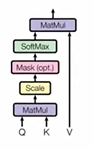

# 4 注意力机制实现步骤

## 4.1 步骤

- **第一步**: 根据注意力计算规则，对 \( Q \)、\( K \)、\( V \) 进行相应的计算。
- **第二步**: 根据第一步采用的计算方法，如果是拼接方法，则需要将 \( Q \) 与第二步的计算结果再进行拼接，如果是转置点积，一般是自注意力，\( Q \) 与 \( V \) 相同，则不需要进行与 \( Q \) 的拼接。
- **第三步**: 最后为了使整个 attention 机制按照指定尺寸输出，使用线性层作用在第二步的结果上做一个线性变换，得到最终对 \( Q \) 的注意力表示。

## 4.2 代码实现

- 常见注意力机制的代码分析：

### 💻 代码解读：Q、K、V 三步走

回顾我们刚才的图书馆类比，代码实现精确对应了三个步骤：

| 步骤 | 代码操作 | 对应含义 |
|------|---------|---------|
| 第一步 | Q与K拼接 → 线性变换 → Softmax | 用需求(Q)匹配标签(K)，算出每本书该花多少时间 |
| 第二步 | 注意力权重 × V（bmm运算） | 按比例读取每本书的实际内容(V) |
| 第三步 | Q与第二步结果拼接 → 线性变换 | 把"原始问题"和"读到的内容"融合，形成最终理解 |

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attn(nn.Module):
    def __init__(self, query_size, key_size, value_size1, value_size2, output_size):
        """
        参数含义：
        - query_size:  Q的最后一维大小（你的"需求"的维度）
        - key_size:    K的最后一维大小（书"标签"的维度）
        - value_size1: V的倒数第二维大小（书架上书的数量）
        - value_size2: V的倒数第一维大小（每本书的"内容"维度）
        - output_size: 最终输出的维度
        """
        super(Attn, self).__init__()
        self.query_size = query_size
        self.key_size = key_size
        self.value_size1 = value_size1
        self.value_size2 = value_size2
        self.output_size = output_size

        # ===== 第一步的线性层：Q和K拼接后 → 计算每个V的权重 =====
        # 对应：把你的需求(Q)和每本书的标签(K)放在一起，
        #      通过一个线性层 + Softmax，算出每本书该花多少时间
        self.attn = nn.Linear(self.query_size + self.key_size, value_size1)

        # ===== 第三步的线性层：Q和注意力结果拼接 → 最终输出 =====
        # 对应：把"原始问题(Q)"和"读到的重要内容(attn_applied)"融合，
        #      形成你对这件事的最终理解
        self.attn_combine = nn.Linear(self.query_size + value_size2, output_size)
        
    def forward(self, Q, K, V):
        """
        Q: 查询 — "我需要什么信息？"     形状: (1, 1, query_size)
        K: 键   — "我是什么，来匹配我"    形状: (1, 1, key_size)
        V: 值   — "匹配到我后，给你内容"   形状: (1, value_size1, value_size2)
        """

        # ============================================
        # 第一步：Q-K匹配 → 算出注意力权重
        # 图书馆类比：用你的需求(Q)去匹配每本书的标签(K)
        # ============================================
        # torch.cat((Q[0], K[0]), 1): 把Q和K在最后一维拼接
        #   → 就像把"你的需求"和"书的标签"放在一起比较
        # self.attn(...): 线性变换，学习怎么从Q+K中提取匹配分数
        # F.softmax(..., dim=1): 把分数变成概率（每本书该花的时间比例）
        attn_weights = F.softmax(
            self.attn(torch.cat((Q[0], K[0]), 1)), dim=1)

        # ============================================
        # 第一步后半：注意力权重 × V → 按比例提取内容
        # 图书馆类比：按时间分配比例去读每本书的实际内容
        # ============================================
        # attn_weights: (value_size1,) → 每本书的阅读时间占比
        # unsqueeze(0): 给它加一个batch维度 → (1, value_size1, value_size2)
        # torch.bmm: 批量矩阵乘法，batch=1时等同于矩阵乘法
        #   注意力权重 × V = 加权平均后的内容
        attn_applied = torch.bmm(attn_weights.unsqueeze(0), V)

        # ============================================
        # 第二步：把原始问题Q和提取的内容拼接
        # 图书馆类比：把"你原本想问什么"和"你读到的内容"放在一起
        # ============================================
        # Q[0]: "我本来就想知道这个"
        # attn_applied[0]: "我通过注意力读到了这些"
        # cat: 两者拼接 → "带着问题去理解答案"
        output = torch.cat((Q[0], attn_applied[0]), 1)

        # ============================================
        # 第三步：线性变换 → 融合成最终输出
        # 图书馆类比：把问题和答案整合，形成你的最终理解
        # ============================================
        # self.attn_combine: 把(Q + 注意力结果)映射到指定输出维度
        # unsqueeze(0): 恢复batch维度，保持三维输出
        output = self.attn_combine(output).unsqueeze(0)
        return output, attn_weights

> - 调用：

In [ ]:
# ===== 维度设置说明 =====
query_size = 32     # Q的维度：你的"需求"用32维向量表示
key_size = 32       # K的维度：书的"标签"用32维向量表示
value_size1 = 32    # V的第一维：有32本"书"（32个待关注的对象）
value_size2 = 64    # V的第二维：每本"书"的内容用64维向量表示
output_size = 64    # 最终输出的维度

attn = Attn(query_size, key_size, value_size1, value_size2, output_size)

# ===== 构造Q、K、V =====
# Q: (batch=1, seq_len=1, query_size=32)  — 1个样本的1个"需求"
Q = torch.randn(1, 1, 32)
# K: (batch=1, seq_len=1, key_size=32)    — 1个样本的1个"标签"
K = torch.randn(1, 1, 32)
# V: (batch=1, num_values=32, value_size2=64) — 1个样本的32个"内容"
#    注意：这里有32个V，每个V是64维，分别对应32个待关注的对象
V = torch.randn(1, 32, 64)

out = attn(Q, K, V)
# out[0]: 注意力机制输出的最终表示 — "带着问题理解后的答案"
# out[1]: 注意力权重分布 — "每本书分别花了多少时间"
print(out[0])  # 输出的特征表示
print(out[1])  # 注意力权重（32个值，加起来=1）

- 输出效果：

tensor([[ 0.4477, -0.0500, -0.2277, -0.3168, -0.4096, -0.5982,  0.1548,
    -0.0771, -0.0951,  0.1833,  0.3128,  0.1260,  0.4420,  0.0495,
    -0.7774, -0.0995,  0.2629,  0.4957,  1.0922,  0.1428,  0.3024,
    -0.2646, -0.0265,  0.0632,  0.3951,  0.1583,  0.1130,  0.5500,
    -0.1887, -0.2816, -0.3800, -0.5741,  0.1342,  0.0244, -0.2217,
    0.1544,  0.1865, -0.2019,  0.4090, -0.4762,  0.3677, -0.2553,
    -0.5199,  0.2290, -0.4407,  0.0663, -0.0182, -0.2168,  0.0913,
    -0.2340,  0.1924, -0.3687,  0.1508,  0.3618, -0.0113,  0.2864,
    -0.1929, -0.6821,  0.0951,  0.1335,  0.3560, -0.3215,  0.6461,
    0.1532]]), grad_fn=<UnscaleBackward0>)

tensor([[0.0395, 0.0342, 0.0200, 0.0471, 0.0177, 0.0209, 0.0244, 0.0465, 0.0346,
    0.0378, 0.0282, 0.0214, 0.0135, 0.0419, 0.0926, 0.0123, 0.0177, 0.0187,
    0.0166, 0.0225, 0.0234, 0.0284, 0.0151, 0.0239, 0.0132, 0.0439, 0.0507,
    0.0419, 0.0352, 0.0392, 0.0546, 0.0224]], grad_fn=<SoftmaxBackward>)

- 更多有关注意力机制的应用我们将在案例中进行详尽的理解分析。